# Camera frame testbench

Interactive ROS bag reader to verify D435 loading **frame by frame** before running
`sync_camera_pairs.py` or `generate_annotations.py` at scale.

1. Edit **paths** below (or set `DATASET` to load from `datasets.json`).
2. Run **Open bag** once — scans bag for timestamps and caches them (slow first run, fast after).
3. Scrub with the slider or edit `FRAME_IDX`.

| Panel | Source |
|-------|--------|
| Color | `sensor_msgs/Image` (rgb8) from `COLOR_TOPIC` |
| Depth | `sensor_msgs/Image` (16UC1 mm) from `DEPTH_TOPIC` |
| Top-down | Depth projected to sensor frame via `CALIBRATION_JSON` (optional) |

**Index modes** (`INDEX_MODE`):
- `bag_idx` — color frame 0 .. N_color-1; nearest depth by timestamp
- `pair` — row in `camera_sync_pairs.csv`; shows matched radar/lidar indices and timing delta

**Frame access**: The index stores each frame's bag-record timestamp so `_load_color(N)`
seeks directly to the right chunk — O(1) rather than scanning from frame 0.
Use **preload** to load many scattered frames with a single bag scan.

In [1]:
from pathlib import Path

# --- Edit these, or set DATASET to auto-load from datasets.json ---
DATASET = "2026.05.10/18-05-08"  # or None

CAMERA_BAG        = None   # /path/to/d435.bag
CAMERA_INDEX      = None   # .npz timestamp cache
CAMERA_SYNC_CSV   = None   # camera_sync_pairs.csv
CALIBRATION_JSON  = None   # d435_to_lidar_calibration.json — enables top-down + proposals
ANNOTATIONS_PATH  = None   # annotations.json — drawn on top-down panel

# bag_idx | pair
INDEX_MODE = "bag_idx"

# Color / depth topics (RealSense ROS driver defaults; change if you remapped)
import sys
_nb_root = Path.cwd()
_sync_dir = _nb_root if (_nb_root / "datasets.json").is_file() else _nb_root / "sync"
if str(_sync_dir) not in sys.path:
    sys.path.insert(0, str(_sync_dir))

from camera_compat import DEFAULT_COLOR_TOPIC, DEFAULT_DEPTH_TOPIC
COLOR_TOPIC = DEFAULT_COLOR_TOPIC
DEPTH_TOPIC = DEFAULT_DEPTH_TOPIC

# --- Auto-load from datasets.json ---
if DATASET:
    from dataset_config import load_dataset_paths
    paths = load_dataset_paths(DATASET)
    print(f"dataset: {DATASET}")
    CAMERA_BAG       = paths.get("camera_bag",      CAMERA_BAG)
    CAMERA_INDEX     = paths.get("camera_index",    CAMERA_INDEX)
    CAMERA_SYNC_CSV  = paths.get("camera_sync_csv", CAMERA_SYNC_CSV)
    CALIBRATION_JSON = paths.get("calibration_json", CALIBRATION_JSON)
    ANNOTATIONS_PATH = paths.get("annotations_path", ANNOTATIONS_PATH)

print("Bag:             ", CAMERA_BAG)
print("Index:           ", CAMERA_INDEX)
print("Sync CSV:        ", CAMERA_SYNC_CSV)
print("Calibration:     ", CALIBRATION_JSON)
print("Annotations:     ", ANNOTATIONS_PATH)
print("Index mode:      ", INDEX_MODE)

dataset: 2026.05.10/18-05-08
Bag:              /Volumes/Seagate Portable Drive/data_collect_mobile/2026.05.10/camera/20260510_212819.bag
Index:            /Users/juntingdeng/Library/CloudStorage/GoogleDrive-juntingd@andrew.cmu.edu/My Drive/CMU/Research/3DImage/sensor/TI/setup_test/code/sync/res/2026.05.10/18-05-08/camera_index.npz
Sync CSV:         /Users/juntingdeng/Library/CloudStorage/GoogleDrive-juntingd@andrew.cmu.edu/My Drive/CMU/Research/3DImage/sensor/TI/setup_test/code/sync/res/2026.05.10/18-05-08/camera_sync_pairs.csv
Calibration:      /Users/juntingdeng/Library/CloudStorage/GoogleDrive-juntingd@andrew.cmu.edu/My Drive/CMU/Research/3DImage/sensor/TI/setup_test/code/sync/res/2026.05.10/18-05-08/d435_calibration.json
Annotations:      /Users/juntingdeng/Library/CloudStorage/GoogleDrive-juntingd@andrew.cmu.edu/My Drive/CMU/Research/3DImage/sensor/TI/setup_test/code/sync/res/2026.05.10/18-05-08/annotations.json
Index mode:       bag_idx


In [2]:
import csv
import time
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np

CODE_ROOT = Path.cwd()
if not (CODE_ROOT / "sync").is_dir() and (CODE_ROOT.parent / "sync").is_dir():
    CODE_ROOT = CODE_ROOT.parent
for _p in [
    str(CODE_ROOT / "sync"),
    str(CODE_ROOT / "sync" / "camera_projection"),
]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from camera_compat import (
    build_camera_index,
    depth_to_display,
    iter_topic_messages,
    load_camera_index,
    parse_ros1_image,
    rgb_to_display,
)
from sync_annotations import (
    boxes_for_pair,
    draw_topdown_boxes,
    load_annotations,
    pick_box_two_clicks,
    save_annotations,
    upsert_box,
)
from sync_utils import format_unix_utc

print("Working dir:", CODE_ROOT)

Working dir: /Users/juntingdeng/Library/CloudStorage/GoogleDrive-juntingd@andrew.cmu.edu/My Drive/CMU/Research/3DImage/sensor/TI/setup_test/code


In [3]:
# --- Open bag (run once) ---

if CAMERA_BAG is None:
    raise RuntimeError("Set CAMERA_BAG in the config cell.")
_bag_path = Path(CAMERA_BAG)
if not _bag_path.is_file():
    raise FileNotFoundError(f"Bag not found: {_bag_path}")

# Resolve index path
if CAMERA_INDEX:
    _index_path = Path(CAMERA_INDEX)
elif CAMERA_SYNC_CSV and Path(CAMERA_SYNC_CSV).parent.is_dir():
    _index_path = Path(CAMERA_SYNC_CSV).parent / "camera_index.npz"
else:
    _index_path = _bag_path.with_suffix(_bag_path.suffix + ".camera_index.npz")

_t0 = time.time()
_index = load_camera_index(_index_path, bag_path=_bag_path)
color_ts         = _index["color_ts"]          # header timestamps, seconds (float64)
depth_ts         = _index["depth_ts"]
color_bag_ts_ns  = _index["color_bag_ts_ns"]   # bag-record timestamps, nanoseconds (int64)
depth_bag_ts_ns  = _index["depth_bag_ts_ns"]
N_COLOR  = int(color_ts.size)
N_DEPTH  = int(depth_ts.size)
print(f"Indexed in {time.time() - _t0:.1f} s")
print(f"Color : {N_COLOR} frames  {format_unix_utc(color_ts[0])} .. {format_unix_utc(color_ts[-1])}")
print(f"Depth : {N_DEPTH} frames  {format_unix_utc(depth_ts[0])} .. {format_unix_utc(depth_ts[-1])}")

# Load sync pairs (pair mode)
SYNC_PAIRS = []
if CAMERA_SYNC_CSV and Path(CAMERA_SYNC_CSV).is_file():
    with open(CAMERA_SYNC_CSV, newline="", encoding="utf-8") as _f:
        for _row in csv.DictReader(_f):
            _ci = int(_row.get("camera_color_idx", _row.get("camera_idx", -1)))
            _di = int(_row.get("camera_depth_idx", _ci))
            if _ci < 0:
                continue
            SYNC_PAIRS.append({
                "pair_idx":   int(_row["pair_idx"]),
                "radar_idx":  int(_row["radar_idx"]),
                "lidar_idx":  int(_row["lidar_idx"]),
                "camera_color_idx": _ci,
                "camera_depth_idx": _di,
                "camera_t":   float(_row.get("camera_t") or 0),
                "delta_ms":   float(_row.get("camera_delta_ms") or 0),
            })
    print(
        f"Sync pairs: {len(SYNC_PAIRS)} rows  "
        f"color_idx {SYNC_PAIRS[0]['camera_color_idx']} .. {SYNC_PAIRS[-1]['camera_color_idx']}"
    )
elif INDEX_MODE == "pair":
    raise RuntimeError("pair mode requires CAMERA_SYNC_CSV.")
else:
    print("No camera_sync_pairs.csv — pair mode disabled.")

SLIDER_MAX = max(0, len(SYNC_PAIRS) - 1) if INDEX_MODE == "pair" else max(0, N_COLOR - 1)
print(f"Slider: INDEX_MODE={INDEX_MODE!r} -> 0 .. {SLIDER_MAX}")

# Load calibration (optional)
_calib = None
if CALIBRATION_JSON and Path(CALIBRATION_JSON).is_file():
    from geometry import load_calibration, depth_to_sensor_points
    _calib = load_calibration(CALIBRATION_JSON)
    print(f"Calibration: {CALIBRATION_JSON}")
else:
    print("No calibration — top-down panel disabled.")

# Load annotations
_annotations = load_annotations(None)
if ANNOTATIONS_PATH and Path(ANNOTATIONS_PATH).is_file():
    _annotations = load_annotations(ANNOTATIONS_PATH)
    _n_boxes = sum(len(v) for v in _annotations.get("objects", {}).values())
    print(f"Annotations: {ANNOTATIONS_PATH} ({_n_boxes} boxes)")

Indexed in 0.0 s
Color : 21896 frames  2026-05-11 01:28:19 UTC .. 2026-05-11 01:43:15 UTC
Depth : 21892 frames  2026-05-11 01:28:19 UTC .. 2026-05-11 01:43:15 UTC
Sync pairs: 6523 rows  color_idx 0 .. 19353
Slider: INDEX_MODE='bag_idx' -> 0 .. 21895
Calibration: /Users/juntingdeng/Library/CloudStorage/GoogleDrive-juntingd@andrew.cmu.edu/My Drive/CMU/Research/3DImage/sensor/TI/setup_test/code/sync/res/2026.05.10/18-05-08/d435_calibration.json
Annotations: /Users/juntingdeng/Library/CloudStorage/GoogleDrive-juntingd@andrew.cmu.edu/My Drive/CMU/Research/3DImage/sensor/TI/setup_test/code/sync/res/2026.05.10/18-05-08/annotations.json (2 boxes)


In [4]:
# --- Frame reading with chunk-level seeking + in-memory cache ---
#
# ROS bags have a chunk index keyed by bag-record timestamps.
# Passing start_ns=<exact bag-record ts> to iter_topic_messages makes rosbags
# seek directly to the right chunk, so each load is O(chunk size) not O(bag size).

_CACHE_SIZE = 64
_color_cache: dict = {}   # color_idx -> np.ndarray (H,W,3 uint8)
_depth_cache: dict = {}   # depth_idx -> np.ndarray (H,W uint16)


def _evict(cache: dict):
    while len(cache) >= _CACHE_SIZE:
        cache.pop(next(iter(cache)))


def _load_color(color_idx: int) -> np.ndarray:
    if color_idx in _color_cache:
        return _color_cache[color_idx]
    _t = time.time()
    target_ns = int(color_bag_ts_ns[int(color_idx)])
    for _bag_ts, raw in iter_topic_messages(_bag_path, COLOR_TOPIC, start_ns=target_ns):
        img = parse_ros1_image(raw)
        arr = np.array(img.data, copy=True)
        _evict(_color_cache)
        _color_cache[color_idx] = arr
        print(f"  color_idx={color_idx} loaded in {time.time()-_t:.3f}s")
        return arr
    raise IndexError(f"color_idx {color_idx}: bag_ts {target_ns} not found in {COLOR_TOPIC}")


def _load_depth(depth_idx: int) -> np.ndarray:
    if depth_idx in _depth_cache:
        return _depth_cache[depth_idx]
    _t = time.time()
    target_ns = int(depth_bag_ts_ns[int(depth_idx)])
    for _bag_ts, raw in iter_topic_messages(_bag_path, DEPTH_TOPIC, start_ns=target_ns):
        img = parse_ros1_image(raw)
        arr = np.array(img.data, copy=True)
        _evict(_depth_cache)
        _depth_cache[depth_idx] = arr
        print(f"  depth_idx={depth_idx} loaded in {time.time()-_t:.3f}s")
        return arr
    raise IndexError(f"depth_idx {depth_idx}: bag_ts {target_ns} not found in {DEPTH_TOPIC}")


def _nearest_depth_idx(color_idx: int) -> int:
    ct = float(color_ts[int(color_idx)])
    return int(np.argmin(np.abs(depth_ts - ct)))


def preload_frames(color_indices, depth_indices=None):
    """Load many frames in one sequential pass — good for consecutive or nearly-consecutive
    ranges where one scan is cheaper than N separate bag-opens."""
    need_color = sorted(set(int(i) for i in color_indices) - _color_cache.keys())
    need_depth = sorted(set(int(i) for i in (depth_indices or [])) - _depth_cache.keys())
    if not need_color and not need_depth:
        return

    if need_color:
        cset = set(need_color)
        max_ci = max(need_color)
        print(f"Preloading {len(need_color)} color frames (scan to idx {max_ci})...")
        for i, (_, raw) in enumerate(iter_topic_messages(_bag_path, COLOR_TOPIC)):
            if i > max_ci:
                break
            if i in cset:
                img = parse_ros1_image(raw)
                _evict(_color_cache)
                _color_cache[i] = np.array(img.data, copy=True)

    if need_depth:
        dset = set(need_depth)
        max_di = max(need_depth)
        print(f"Preloading {len(need_depth)} depth frames (scan to idx {max_di})...")
        for i, (_, raw) in enumerate(iter_topic_messages(_bag_path, DEPTH_TOPIC)):
            if i > max_di:
                break
            if i in dset:
                img = parse_ros1_image(raw)
                _evict(_depth_cache)
                _depth_cache[i] = np.array(img.data, copy=True)
    print("Preload done.")


def camera_fingerprint(color: np.ndarray, depth: np.ndarray) -> dict:
    mean_rgb = tuple(float(v) for v in color.reshape(-1, 3).mean(axis=0))
    valid = depth[depth > 0]
    coverage = float(valid.size) / float(depth.size) if depth.size > 0 else 0.0
    median_m = float(np.median(valid)) * 1e-3 if valid.size > 0 else float("nan")
    return {"mean_rgb": mean_rgb, "depth_coverage": coverage, "depth_median_m": median_m}


print("Frame reading functions ready (chunk-level seeking enabled).")

Frame reading functions ready (chunk-level seeking enabled).


In [5]:
# --- Check depth resolution + intrinsics hint ---
# Loads the first depth frame (chunk-seeking) to confirm resolution,
# then prints the camera_info topic path to look up exact intrinsics.

import time as _time_mod

_t_start = _time_mod.time()
print("Opening bag for first depth frame (chunk seek)...")
depth0 = _load_depth(0)
print(f"Done in {_time_mod.time() - _t_start:.1f}s")

h, w = depth0.shape
print(f"\nDepth resolution: {w} x {h}")
print()
print("To get exact intrinsics for your unit, run in terminal:")
print("  rs-enumerate-devices -c | grep -A 30 'Depth'")
print()
print("Then update d435_calibration.json with the fx/fy/cx/cy values.")

Opening bag for first depth frame (chunk seek)...
  depth_idx=0 loaded in 264.491s
Done in 264.5s

Depth resolution: 848 x 480

To get exact intrinsics for your unit, run in terminal:
  rs-enumerate-devices -c | grep -A 30 'Depth'

Then update d435_calibration.json with the fx/fy/cx/cy values.


In [6]:
# --- Render + show ---

_SCENE = (-15.0, 15.0, 0.0, 30.0)  # lat_min, lat_max, fwd_min, fwd_max  (meters)
_TD_RES = 0.15                       # meters per top-down bin

try:
    from generate_annotations import proposals_from_points as _proposals_fn
    _PROPOSALS_AVAILABLE = True
except ImportError:
    _PROPOSALS_AVAILABLE = False

import json as _json

_DEFAULT_PROPOSAL_PARAMS = dict(
    stride=4, min_depth_m=0.5, max_depth_m=30.0,
    scene_lateral=(-15.0, 15.0), scene_forward=(0.5, 30.0),
    grid_res_m=0.25, min_component_points=25,
    min_box_lateral_m=0.2, min_box_forward_m=0.2,
    max_box_lateral_m=6.0, max_box_forward_m=8.0,
    box_percentiles=(5.0, 95.0), label="object", color="yellow",
    replace_generated=False,
    min_height_m=-1.0,  # drop ground returns; tune to -(camera height above ground in m)
)

# File-backed proposal cache: keys are str(depth_idx), values are lists of box dicts.
_proposal_cache_path = (
    Path(CAMERA_INDEX).parent / "proposal_cache.json"
    if CAMERA_INDEX else Path("proposal_cache.json")
)
_proposal_cache: dict = {}


def _save_proposal_cache():
    """Write cache as one entry per line: '"depth_idx": [{...}]'"""
    items = list(_proposal_cache.items())
    with open(_proposal_cache_path, "w", encoding="utf-8") as _f:
        _f.write("{\n")
        for i, (key, val) in enumerate(items):
            comma = "," if i < len(items) - 1 else ""
            _f.write(f'{_json.dumps(key)}: {_json.dumps(val)}{comma}\n')
        _f.write("}\n")


if _proposal_cache_path.is_file():
    with open(_proposal_cache_path, "r", encoding="utf-8") as _f:
        _proposal_cache = _json.load(_f)
    _save_proposal_cache()  # rewrite in one-line-per-frame format
    print(f"Loaded proposal cache: {len(_proposal_cache)} entries from {_proposal_cache_path}")
else:
    print(f"No proposal cache yet — will create at {_proposal_cache_path}")


def _make_proposal_args(params):
    import types
    ns = types.SimpleNamespace(**params)
    ns.scene_lateral = list(params["scene_lateral"])
    ns.scene_forward = list(params["scene_forward"])
    ns.box_percentiles = list(params["box_percentiles"])
    return ns


def _get_proposals(depth_idx: int, depth_arr) -> list:
    """Return proposals for depth_idx, computing + saving to cache file if not stored."""
    key = str(depth_idx)
    if key not in _proposal_cache:
        params = globals().get("PROPOSAL_PARAMS", _DEFAULT_PROPOSAL_PARAMS)
        args   = _make_proposal_args(params)
        pts    = depth_to_sensor_points(depth_arr, _calib, stride=params.get("stride", 4),
                                        min_height_m=params.get("min_height_m"))
        _proposal_cache[key] = _proposals_fn(pts, args)
        _save_proposal_cache()
    return _proposal_cache[str(depth_idx)]


def _depth_to_topdown(depth_arr: np.ndarray):
    """Project depth frame to top-down density image. Returns (img, extent)."""
    pts = depth_to_sensor_points(depth_arr, _calib, stride=3)
    lat0, lat1, fwd0, fwd1 = _SCENE
    res = _TD_RES
    n_lat = int(np.ceil((lat1 - lat0) / res))
    n_fwd = int(np.ceil((fwd1 - fwd0) / res))
    fwd  = pts["forward"]
    lat  = pts["lateral"]
    dm   = pts["depth_m"]
    valid = (
        np.isfinite(fwd) & np.isfinite(lat)
        & (dm > 0.1) & (dm < 30.0)
        & (fwd >= fwd0) & (fwd <= fwd1)
        & (lat >= lat0) & (lat <= lat1)
    )
    img = np.zeros((n_fwd, n_lat), dtype=np.float32)
    if np.any(valid):
        ci = np.clip(np.floor((lat[valid] - lat0) / res).astype(int), 0, n_lat - 1)
        ri = np.clip(np.floor((fwd[valid] - fwd0) / res).astype(int), 0, n_fwd - 1)
        np.add.at(img, (ri, ci), 1)
    return img, (lat0, lat1, fwd0, fwd1)


def resolve_indices(frame_idx: int) -> dict:
    frame_idx = int(frame_idx)
    if INDEX_MODE == "pair":
        if not (0 <= frame_idx < len(SYNC_PAIRS)):
            raise IndexError(f"pair {frame_idx} out of range [0, {len(SYNC_PAIRS)})")
        row = SYNC_PAIRS[frame_idx]
        return {
            "color_idx":  row["camera_color_idx"],
            "depth_idx":  row["camera_depth_idx"],
            "pair_idx":   row["pair_idx"],
            "radar_idx":  row["radar_idx"],
            "lidar_idx":  row["lidar_idx"],
            "camera_t":   row["camera_t"],
            "delta_ms":   row["delta_ms"],
            "slider_idx": frame_idx,
        }
    else:
        if not (0 <= frame_idx < N_COLOR):
            raise IndexError(f"color_idx {frame_idx} out of range [0, {N_COLOR})")
        return {
            "color_idx":  frame_idx,
            "depth_idx":  _nearest_depth_idx(frame_idx),
            "slider_idx": frame_idx,
        }


def render_panels(frame_idx: int) -> dict:
    meta = resolve_indices(frame_idx)
    t0   = time.time()
    color = _load_color(meta["color_idx"])
    depth = _load_depth(meta["depth_idx"])
    meta["load_s"]  = time.time() - t0
    meta["color_t"] = float(color_ts[meta["color_idx"]])
    meta["depth_t"] = float(depth_ts[meta["depth_idx"]])
    meta["fp"]      = camera_fingerprint(color, depth)
    out = {"color": color, "depth": depth, "meta": meta}
    if _calib is not None:
        out["topdown"], out["topdown_extent"] = _depth_to_topdown(depth)
    return out


def show_frame(frame_idx: int, *, compare_prev: bool = True, show_proposals: bool = True):
    global _last_frame, _last_panels
    panels = render_panels(frame_idx)
    meta   = panels["meta"]
    fp     = meta["fp"]
    ts_str = format_unix_utc(meta["color_t"])

    n_panels = 3 if "topdown" in panels else 2
    fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 4.5))

    axes[0].imshow(rgb_to_display(panels["color"]))
    axes[0].set_title("Color (RGB)")
    axes[0].set_xlabel("px")
    axes[0].set_ylabel("px")

    depth_disp = depth_to_display(panels["depth"], max_m=10.0)
    im1 = axes[1].imshow(depth_disp, cmap="plasma", vmin=0, vmax=1)
    axes[1].set_title(
        f"Depth (0–10 m)  coverage={fp['depth_coverage']:.1%}  "
        f"median={fp['depth_median_m']:.2f} m"
    )
    axes[1].set_xlabel("px")
    axes[1].set_ylabel("px")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, label="near→far")

    if "topdown" in panels:
        td  = panels["topdown"]
        ext = panels["topdown_extent"]
        vmax = float(np.percentile(td[td > 0], 99)) if np.any(td > 0) else 1.0
        im2 = axes[2].imshow(
            td, origin="lower",
            extent=(ext[0], ext[1], ext[2], ext[3]),
            aspect="equal", cmap="viridis",
            vmin=0, vmax=max(vmax, 1.0),
        )

        ann_boxes = boxes_for_pair(_annotations, meta.get("pair_idx"))
        if ann_boxes:
            draw_topdown_boxes(axes[2], ann_boxes)

        n_proposals = 0
        if show_proposals and _PROPOSALS_AVAILABLE and _calib is not None:
            prop_boxes = _get_proposals(meta["depth_idx"], panels["depth"])
            n_proposals = len(prop_boxes)
            for box in prop_boxes:
                lmin, lmax = box["lateral"]
                fmin, fmax = box["forward"]
                rect = plt.Rectangle(
                    (lmin, fmin), lmax - lmin, fmax - fmin,
                    linewidth=1.5, edgecolor="yellow", facecolor="none",
                )
                axes[2].add_patch(rect)
                axes[2].text(
                    lmin, fmax,
                    f"{box['median_depth_m']:.1f}m",
                    fontsize=6.5, color="yellow", va="bottom",
                )

        cached_str = " (cached)" if str(meta["depth_idx"]) in _proposal_cache else ""
        proposal_str = f"  proposals={n_proposals}{cached_str}" if (show_proposals and _PROPOSALS_AVAILABLE) else ""
        axes[2].set_title(f"Top-down depth projection (X=fwd, Y=lat){proposal_str}")
        axes[2].set_xlabel("lateral (m)")
        axes[2].set_ylabel("forward (m)")
        plt.colorbar(im2, ax=axes[2], fraction=0.046, label="pts/cell")

    pair_line = ""
    if INDEX_MODE == "pair":
        pair_line = (
            f"  pair={meta.get('pair_idx')}  "
            f"radar={meta.get('radar_idx')}  lidar={meta.get('lidar_idx')}  "
            f"delta={meta.get('delta_ms', 0):.1f}ms"
        )
    diff_str = ""
    if compare_prev and "_last_panels" in globals() and _last_frame is not None:
        for key in ("color", "depth"):
            d = float(np.mean(np.abs(
                panels[key].astype(np.float32) - _last_panels[key].astype(np.float32)
            )))
            diff_str += f"  mean|Δ{key}|={d:.1f}"

    fig.suptitle(
        f"{INDEX_MODE}={frame_idx}  color_idx={meta['color_idx']}  "
        f"depth_idx={meta['depth_idx']}  t={ts_str}  "
        f"load={meta['load_s']:.2f}s{pair_line}{diff_str}",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()

    _last_frame  = int(frame_idx)
    _last_panels = panels
    return panels


print("render / show_frame ready.")

Loaded proposal cache: 6 entries from /Users/juntingdeng/Library/CloudStorage/GoogleDrive-juntingd@andrew.cmu.edu/My Drive/CMU/Research/3DImage/sensor/TI/setup_test/code/sync/res/2026.05.10/18-05-08/proposal_cache.json
render / show_frame ready.


---
## Proposal preview

Runs the same pipeline as `generate_annotations.py` on a **single frame**:

```
depth pixels  →  3D camera frame  →  sensor frame (forward/lateral)
    →  occupancy grid  →  connected components  →  bounding boxes
```

Tune `PROPOSAL_PARAMS` to find good thresholds before running at scale.
Requires `CALIBRATION_JSON` to be set.

In [7]:
import types

# Import the clustering logic directly from generate_annotations
from generate_annotations import connected_components, filter_points, proposals_from_points

# --- Tunable parameters (mirrors generate_annotations.py CLI flags) ---
PROPOSAL_PARAMS = dict(
    stride               = 4,       # pixel subsampling (lower = denser but slower)
    min_depth_m          = 0.5,
    max_depth_m          = 30.0,
    scene_lateral        = (-15.0, 15.0),   # meters
    scene_forward        = (0.5,   30.0),   # meters
    grid_res_m           = 0.25,    # top-down grid cell size
    min_component_points = 25,      # minimum grid cells in a CC to form a box
    min_box_lateral_m    = 0.2,
    min_box_forward_m    = 0.2,
    max_box_lateral_m    = 6.0,
    max_box_forward_m    = 8.0,
    box_percentiles      = (5.0, 95.0),
    label                = "object",
    color                = "yellow",
    replace_generated    = False,
    min_height_m         = -1.0,    # drop ground returns; tune to -(camera height above ground in m)
)


def _args_from_params(params: dict) -> types.SimpleNamespace:
    """Convert the params dict into the argparse-style namespace that the
    generate_annotations functions expect."""
    ns = types.SimpleNamespace(**params)
    ns.scene_lateral = list(params["scene_lateral"])
    ns.scene_forward = list(params["scene_forward"])
    ns.box_percentiles = list(params["box_percentiles"])
    return ns


def preview_proposals(frame_idx: int, **param_overrides):
    """Show 4 panels for one frame: RGB | depth | occupancy grid | proposals.

    Pass keyword arguments to override any entry in PROPOSAL_PARAMS, e.g.
        preview_proposals(42, min_depth_m=1.0, max_box_lateral_m=4.0)
    """
    if _calib is None:
        raise RuntimeError("Set CALIBRATION_JSON in the config cell.")

    params = {**PROPOSAL_PARAMS, **param_overrides}
    args   = _args_from_params(params)
    meta   = resolve_indices(int(frame_idx))
    depth  = _load_depth(meta["depth_idx"])
    color  = _load_color(meta["color_idx"])

    # Project full depth frame to sensor frame (with height filter)
    t0   = time.time()
    pts  = depth_to_sensor_points(depth, _calib, stride=params["stride"],
                                  min_height_m=params.get("min_height_m"))
    # Build occupancy grid (for visual inspection)
    lat0, lat1 = params["scene_lateral"]
    fwd0, fwd1 = params["scene_forward"]
    res    = params["grid_res_m"]
    n_cols = max(1, int(np.ceil((lat1 - lat0) / res)))
    n_rows = max(1, int(np.ceil((fwd1 - fwd0) / res)))
    fpts   = filter_points(pts, args)
    occ    = np.zeros((n_rows, n_cols), dtype=bool)
    if fpts["forward"].size > 0:
        ci = np.clip(np.floor((fpts["lateral"] - lat0) / res).astype(int), 0, n_cols - 1)
        ri = np.clip(np.floor((fpts["forward"] - fwd0) / res).astype(int), 0, n_rows - 1)
        occ[ri, ci] = True
    # Run clustering → boxes
    boxes   = proposals_from_points(pts, args)
    elapsed = time.time() - t0

    # --- Plot ---
    fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))

    # Panel 1: color
    axes[0].imshow(rgb_to_display(color))
    axes[0].set_title("Color (RGB)")
    axes[0].set_xlabel("px"); axes[0].set_ylabel("px")

    # Panel 2: depth
    axes[1].imshow(depth_to_display(depth, max_m=params["max_depth_m"]),
                   cmap="plasma", vmin=0, vmax=1)
    axes[1].set_title(f"Depth (0–{params['max_depth_m']:.0f} m)")
    axes[1].set_xlabel("px"); axes[1].set_ylabel("px")

    # Panel 3: occupancy grid (one cell per grid_res_m square)
    axes[2].imshow(occ, origin="lower",
                   extent=(lat0, lat1, fwd0, fwd1),
                   aspect="equal", cmap="Blues", interpolation="nearest")
    axes[2].set_title(f"Occupancy grid  res={res}m  {int(occ.sum())} occupied cells")
    axes[2].set_xlabel("lateral (m)"); axes[2].set_ylabel("forward (m)")

    # Panel 4: projected points + proposal boxes
    if fpts["forward"].size > 0:
        sc = axes[3].scatter(
            fpts["lateral"], fpts["forward"],
            s=0.5, c=fpts["depth_m"],
            cmap="viridis", vmin=params["min_depth_m"], vmax=params["max_depth_m"],
        )
        plt.colorbar(sc, ax=axes[3], fraction=0.046, label="depth (m)")
    for box in boxes:
        lmin, lmax = box["lateral"]
        fmin, fmax = box["forward"]
        rect = plt.Rectangle(
            (lmin, fmin), lmax - lmin, fmax - fmin,
            linewidth=1.5, edgecolor="yellow", facecolor="none",
        )
        axes[3].add_patch(rect)
        axes[3].text(
            lmin, fmax,
            f"{box['median_depth_m']:.1f}m  {box['n_depth_points']}pts",
            fontsize=6.5, color="yellow", va="bottom",
        )
    axes[3].set_xlim(lat0, lat1); axes[3].set_ylim(fwd0, fwd1)
    axes[3].set_aspect("equal")
    axes[3].set_title(f"Proposals: {len(boxes)} boxes  ({elapsed * 1e3:.0f} ms)")
    axes[3].set_xlabel("lateral (m)"); axes[3].set_ylabel("forward (m)")

    ts_str = format_unix_utc(float(color_ts[meta["color_idx"]]))
    fig.suptitle(
        f"{INDEX_MODE}={frame_idx}  color_idx={meta['color_idx']}  "
        f"depth_idx={meta['depth_idx']}  t={ts_str}",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()
    return boxes


print("preview_proposals ready.  Call: preview_proposals(FRAME_IDX)")

preview_proposals ready.  Call: preview_proposals(FRAME_IDX)


  color_idx=0 loaded in 261.748s


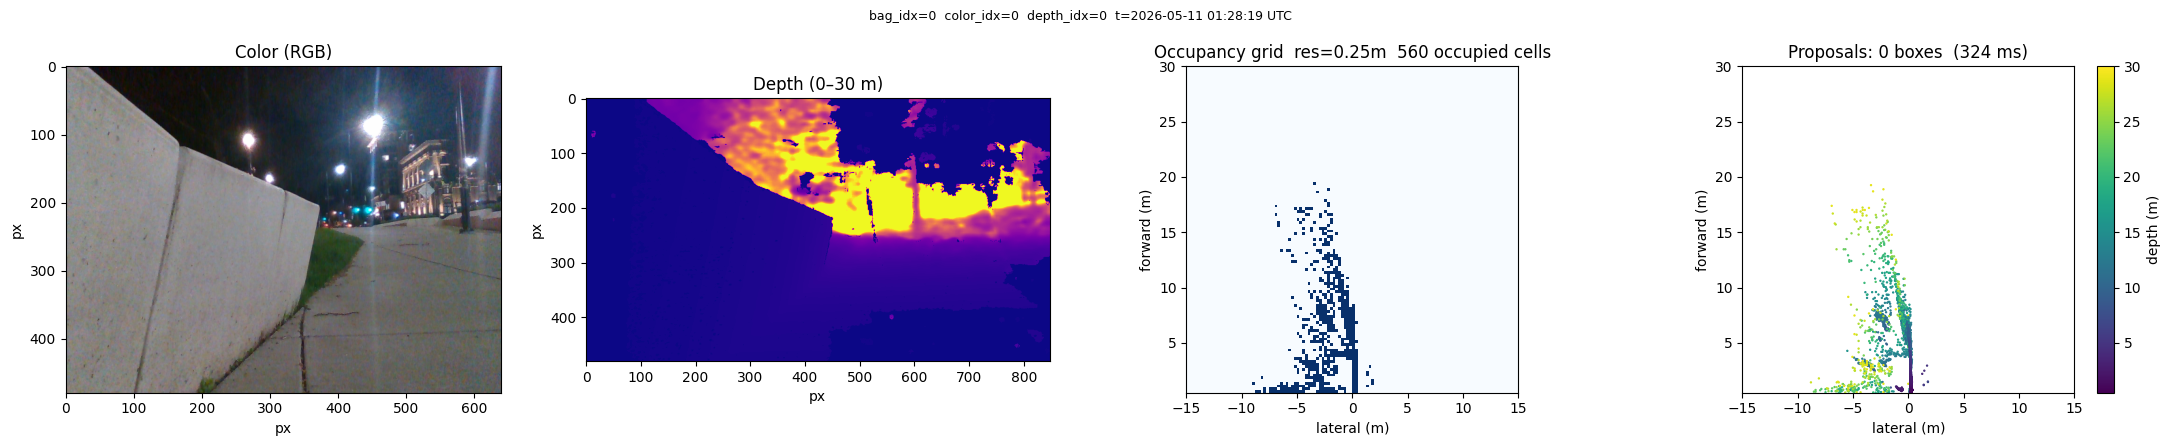

[]

In [8]:
# --- Run proposal preview on one frame ---
# Override any PROPOSAL_PARAMS key inline, e.g.:
#   preview_proposals(FRAME_IDX, grid_res_m=0.15, min_component_points=10)
FRAME_IDX = 0
preview_proposals(FRAME_IDX)

  color_idx=1000 loaded in 259.498s
  depth_idx=999 loaded in 257.940s


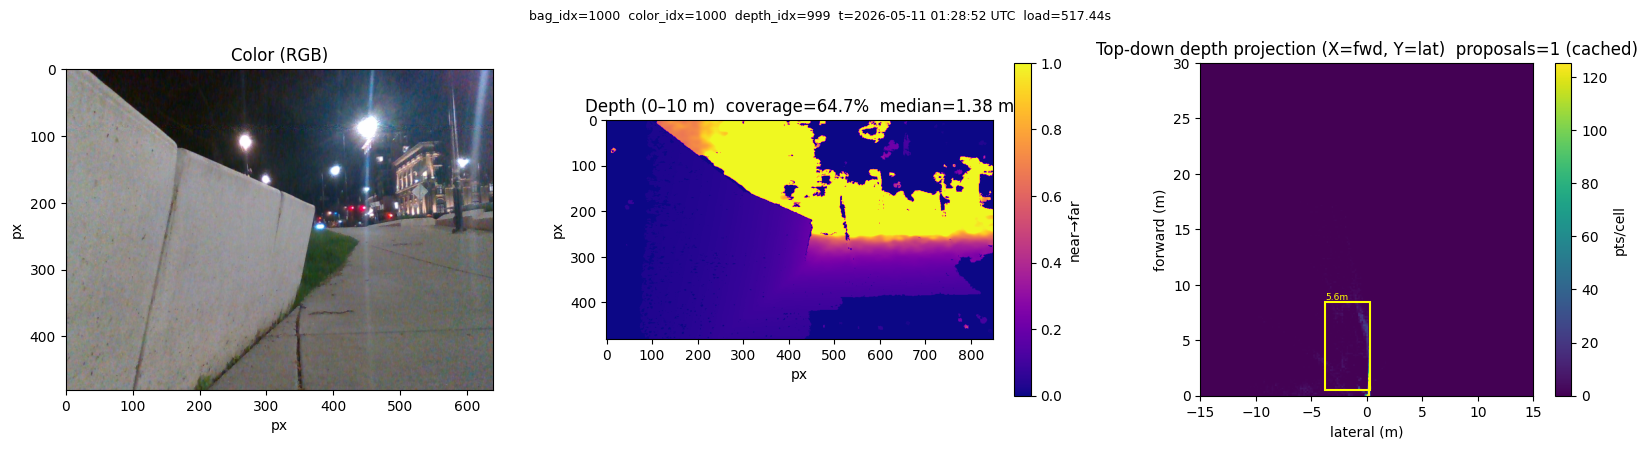

{'color': array([[[152, 149, 106],
         [156, 153, 110],
         [165, 155, 116],
         ...,
         [ 98,  96, 112],
         [103,  80, 121],
         [ 93,  70, 111]],
 
        [[156, 150, 112],
         [158, 152, 114],
         [156, 149, 118],
         ...,
         [ 91,  99, 118],
         [ 98,  79, 123],
         [ 92,  73, 117]],
 
        [[159, 146, 122],
         [158, 145, 121],
         [152, 145, 126],
         ...,
         [ 85, 103, 130],
         [ 95,  79, 129],
         [ 88,  72, 122]],
 
        ...,
 
        [[130, 130, 124],
         [139, 139, 133],
         [149, 141, 129],
         ...,
         [107,  98, 105],
         [ 89,  92,  91],
         [ 92,  95,  94]],
 
        [[138, 138, 132],
         [136, 136, 130],
         [147, 138, 129],
         ...,
         [107,  98, 101],
         [ 95,  95,  95],
         [ 95,  95,  95]],
 
        [[140, 138, 130],
         [140, 138, 130],
         [144, 136, 124],
         ...,
         [108,  98,

In [9]:
# --- Manual frame index: edit and re-run this cell ---
FRAME_IDX = 1000
show_frame(FRAME_IDX)

In [10]:
# --- Annotate: click two corners on top-down panel, save to ANNOTATIONS_PATH ---
# Requires CALIBRATION_JSON and INDEX_MODE = "pair".
# Tip: use %matplotlib widget if clicks don't register.


def annotate_camera_pair(
    pair_idx: int,
    *,
    label: str = "object",
    box_id: str = "",
    color: str = "cyan",
):
    global _annotations
    if ANNOTATIONS_PATH is None:
        raise RuntimeError("Set ANNOTATIONS_PATH in the config cell.")
    if _calib is None:
        raise RuntimeError("Set CALIBRATION_JSON in the config cell.")
    slider_idx = next(
        (i for i, r in enumerate(SYNC_PAIRS) if r["pair_idx"] == pair_idx), None
    )
    if slider_idx is None:
        raise KeyError(f"pair_idx {pair_idx} not found in sync CSV.")

    panels = render_panels(slider_idx)
    td = panels.get("topdown")
    if td is None:
        raise RuntimeError("No top-down panel — check CALIBRATION_JSON.")
    ext  = panels["topdown_extent"]
    vmax = float(np.percentile(td[td > 0], 99)) if np.any(td > 0) else 1.0
    meta = panels["meta"]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(
        td, origin="lower",
        extent=(ext[0], ext[1], ext[2], ext[3]),
        aspect="equal", cmap="viridis",
        vmin=0, vmax=max(vmax, 1.0),
    )
    draw_topdown_boxes(ax, boxes_for_pair(_annotations, pair_idx))
    ax.set_title(
        f"Annotate pair={pair_idx}  "
        f"color={meta['color_idx']}  depth={meta['depth_idx']}"
    )
    ax.set_xlabel("lateral (m)")
    ax.set_ylabel("forward (m)")
    plt.tight_layout()
    plt.show()

    box = pick_box_two_clicks(
        ax, label=label,
        box_id=box_id or f"pair{pair_idx}_cam_{label}",
        color=color,
    )
    if box is None:
        return None
    _annotations = upsert_box(_annotations, pair_idx, box)
    save_annotations(_annotations, ANNOTATIONS_PATH)
    print(f"Saved to {ANNOTATIONS_PATH}: pair {pair_idx} -> {box}")
    return box


# Example (INDEX_MODE = "pair"): annotate_camera_pair(42, label="pedestrian")

In [11]:
# --- Interactive slider (requires ipywidgets) ---
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    print("Install ipywidgets for slider: pip install ipywidgets")
else:
    start = SLIDER_MAX // 2
    slider = widgets.IntSlider(
        value=min(start, SLIDER_MAX),
        min=0, max=int(SLIDER_MAX), step=1,
        description=INDEX_MODE,
        continuous_update=False,
        layout=widgets.Layout(width="80%"),
    )
    out = widgets.interactive_output(show_frame, {"frame_idx": slider})
    display(widgets.VBox([slider, out]))

In [12]:
# --- Quick probe: first / mid / last frame ---
# Each _load call now seeks directly to the right chunk, so no batch preload needed.

if INDEX_MODE == "pair" and SYNC_PAIRS:
    probe_slider = sorted({0, len(SYNC_PAIRS) // 2, len(SYNC_PAIRS) - 1})
else:
    probe_slider = sorted({0, SLIDER_MAX // 2, SLIDER_MAX})

probe_meta = [resolve_indices(i) for i in probe_slider]

rows = []
for slider_idx, meta in zip(probe_slider, probe_meta):
    color = _load_color(meta["color_idx"])
    depth = _load_depth(meta["depth_idx"])
    fp    = camera_fingerprint(color, depth)
    rows.append((
        slider_idx,
        meta["color_idx"],
        meta["depth_idx"],
        fp["depth_coverage"],
        fp["depth_median_m"],
        format_unix_utc(float(color_ts[meta["color_idx"]])),
    ))

print(f"{'slider':>6}  {'color_idx':>9}  {'depth_idx':>9}  {'depth_cov':>9}  {'med_m':>6}  timestamp")
for r in rows:
    print(f"{r[0]:6d}  {r[1]:9d}  {r[2]:9d}  {r[3]:9.1%}  {r[4]:6.2f}  {r[5]}")

_means = [_load_color(m["color_idx"]).mean() for m in probe_meta]
if len(set(round(v, 1) for v in _means)) < 2:
    print("WARN: color frames look identical — check INDEX_MODE / bag topics")
else:
    print("OK: color frames differ across probe indices")

  color_idx=21895 loaded in 303.093s
  depth_idx=21890 loaded in 294.505s
slider  color_idx  depth_idx  depth_cov   med_m  timestamp
     0          0          0      65.5%    1.34  2026-05-11 01:28:19 UTC
 10947      10947      10944      58.8%    6.16  2026-05-11 01:35:40 UTC
 21895      21895      21890      75.2%    0.80  2026-05-11 01:43:15 UTC
OK: color frames differ across probe indices


In [13]:
# --- Proposal sanity check: count boxes for depth frames ---
# If _depth_cache has fewer than NUM_CHECK_FRAMES entries, loads more via one bag scan.
# Results are stored in _proposal_cache (file-backed) for reuse by show_frame.

NUM_CHECK_FRAMES = 4   # set to None to check all currently cached frames

if not _PROPOSALS_AVAILABLE:
    print("generate_annotations not importable — skipping.")
elif _calib is None:
    print("No calibration loaded — skipping.")
else:
    params = globals().get("PROPOSAL_PARAMS", _DEFAULT_PROPOSAL_PARAMS)
    args   = _make_proposal_args(params)

    # Auto-load more frames if cache is smaller than requested.
    if NUM_CHECK_FRAMES is not None and len(_depth_cache) < NUM_CHECK_FRAMES:
        already  = set(_depth_cache.keys())
        need     = NUM_CHECK_FRAMES - len(already)
        candidates = [int(i) for i in np.linspace(0, N_DEPTH - 1, NUM_CHECK_FRAMES * 2, dtype=int)]
        to_load    = sorted(set(candidates) - already)[:need]
        print(f"_depth_cache has {len(already)} frame(s), need {NUM_CHECK_FRAMES}. "
              f"Loading {len(to_load)} more via one bag scan...")
        preload_frames([], depth_indices=to_load)

    cached = sorted(_depth_cache.items())
    if NUM_CHECK_FRAMES is not None:
        cached = cached[:NUM_CHECK_FRAMES]

    if not cached:
        print("No frames in cache.")
    else:
        new_entries = 0
        results = []
        for depth_idx, depth_arr in cached:
            key = str(depth_idx)
            if key not in _proposal_cache:
                pts = depth_to_sensor_points(depth_arr, _calib, stride=params.get("stride", 4),
                                             min_height_m=params.get("min_height_m"))
                _proposal_cache[key] = _proposals_fn(pts, args)
                new_entries += 1
            results.append((depth_idx, len(_proposal_cache[key])))

        if new_entries:
            _save_proposal_cache()
            print(f"Saved {new_entries} new entries to {_proposal_cache_path}")

        n_zero    = sum(1 for _, n in results if n == 0)
        n_nonzero = len(results) - n_zero
        print(f"Checked {len(results)} frames: {n_nonzero} with boxes, {n_zero} with 0 boxes")
        print(f"Proposal cache total: {len(_proposal_cache)} entries")

        if NUM_CHECK_FRAMES is None:
            _out_path = Path(CAMERA_INDEX).parent / "proposal_check.txt" if CAMERA_INDEX else Path("proposal_check.txt")
            with open(_out_path, "w") as _f:
                _f.write("depth_idx   n_boxes\n")
                for depth_idx, n in results:
                    _f.write(f"{depth_idx:10d}  {n:7d}\n")
            print(f"Per-frame table saved to: {_out_path}")
        else:
            print()
            print(f"{'depth_idx':>10}  {'n_boxes':>7}")
            for depth_idx, n in results:
                print(f"{depth_idx:10d}  {n:7d}")

Checked 4 frames: 2 with boxes, 2 with 0 boxes
Proposal cache total: 6 entries

 depth_idx  n_boxes
         0        0
       999        1
     10944        1
     21890        0
